<a href="https://colab.research.google.com/github/JanIsaac-1/Intelligent-Task-Allocation-System/blob/updates/train_sbert_iltas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install sentence-transformers and scientific stack
!pip install -q sentence-transformers torch pandas scikit-learn matplotlib seaborn

import os
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation, util

# Check if GPU is enabled in Colab (Runtime -> Change runtime type -> T4 GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Active PyTorch Compute Device: {device.upper()}")
if device == "cuda":
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

/tmp/ipykernel_798/940805080.py:13: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation, util
/tmp/ipykernel_798/940805080.py:13: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation, util


Active PyTorch Compute Device: CUDA
GPU Name: Tesla T4


In [2]:
from google.colab import files
uploaded = files.upload()

csv_path = "field_tasks_dataset.csv"
df = pd.read_csv(csv_path)

print(f"Dataset Successfully Loaded!")
print(f"Total Records: {len(df):,} rows")
print(f"Columns: {list(df.columns)}")

# Display domain distribution summary
print("\n Domain Sample Counts (100 pairs per domain):")
display(df['domain'].value_counts())

Saving field_tasks_dataset.csv to field_tasks_dataset.csv
Dataset Successfully Loaded!
Total Records: 2,200 rows
Columns: ['id', 'domain', 'task_description', 'agent_skill_profile']

 Domain Sample Counts (100 pairs per domain):


,count
domain,
Solar PV & Hybrid Inverter Systems,100
Fiber Optic & ISP Last-Mile Splicing,100
CCTV Surveillance & Biometric Access Control,100
Borehole & Submersible Water Pumps,100
Fumigation & Pest Control Services,100
"Satellite TV, DStv & Home Wi-Fi Setup",100
Data Center Precision Cooling & CRAC (HVAC),100
Standby Diesel Generators & ATS Changeovers,100
Domestic Home Appliance Repair,100


In [3]:
# Display 4 random sample rows from different domains
sample_df = df[['domain', 'task_description', 'agent_skill_profile']].sample(4, random_state=42)
for idx, row in sample_df.iterrows():
    print("="*80)
    print(f"[DOMAIN: {row['domain']}]")
    print(f"Task Description:\n   {row['task_description']}")
    print(f"Agent Skill Profile:\n   {row['agent_skill_profile']}")
print("="*80)

[DOMAIN: Commercial Plumbing & High-Rise Booster Systems]
Task Description:
   Inspect water supply pump manifolds, float valves, and fire hose reels across commercial building floors.
Agent Skill Profile:
   Master Plumber & Pipefitter holding PPR Socket Fusion Certified certification, specialized in high-pressure water booster pump repair, ppr socket fusion welding, and sewer line rodding. Experienced in field diagnostics, emergency service restoration, and standard commercial plumbing & high-rise booster systems procedures.
[DOMAIN: Borehole & Submersible Water Pumps]
Task Description:
   Pressure surge tank on borehole line has ruptured internal rubber bladder, causing the pump to short-cycle on and off rapidly.
Agent Skill Profile:
   Borehole & Pump Systems Engineer holding WRA Borehole Installation License certification, specialized in deep-well riser pipe retrieval, borehole yield flow rate testing, and water pressure switch calibration. Experienced in field diagnostics, emerge

In [5]:
train_df, val_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df['domain']
)

print(f"Training Samples:   {len(train_df)} pairs (80%)")
print(f"Validation Samples: {len(val_df)} pairs (20%)")

# Format training pairs into SBERT InputExamples
train_examples = []
for _, row in train_df.iterrows():
    train_examples.append(
        InputExample(texts=[row['task_description'], row['agent_skill_profile']])
    )

# PyTorch DataLoader (batch_size=16 for optimal in-batch contrastive learning)
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)
print(f"DataLoader initialized with {len(train_dataloader)} mini-batches per epoch.")

Training Samples:   1760 pairs (80%)
Validation Samples: 440 pairs (20%)
DataLoader initialized with 110 mini-batches per epoch.


In [6]:
val_sentences1 = val_df['task_description'].tolist()
val_sentences2 = val_df['agent_skill_profile'].tolist()
val_labels = [1.0] * len(val_df)

# Add cross-domain negative pairs
shuffled_profiles = val_df['agent_skill_profile'].sample(frac=1.0, random_state=99).tolist()
for task, neg_prof in zip(val_sentences1[:150], shuffled_profiles[:150]):
    val_sentences1.append(task)
    val_sentences2.append(neg_prof)
    val_labels.append(0.0)

evaluator = evaluation.BinaryClassificationEvaluator(
    sentences1=val_sentences1,
    sentences2=val_sentences2,
    labels=val_labels,
    name="kenyan_field_val_benchmark"
)

print(f"Evaluator ready with {len(val_labels)} evaluation pairs.")

Evaluator ready with 590 evaluation pairs.


In [7]:
def extract_score(eval_output):
        """Extracts the accuracy float from the evaluator dictionary."""
        if isinstance(eval_output, dict):
            for key, val in eval_output.items():
                if "accuracy" in key:
                    return float(val)
            # Fallback: take first numeric value in dict
            for val in eval_output.values():
                if isinstance(val, (int, float)):
                    return float(val)
        return float(eval_output)

base_model_name = "all-MiniLM-L6-v2"
print(f"Downloading Base Foundation Model: {base_model_name}...")
model = SentenceTransformer(base_model_name, device=device)

print("Running Baseline Evaluation...")
baseline_results = evaluator(model)
baseline_score = extract_score(baseline_results)
print(f"BASELINE ACCURACY (Before Fine-Tuning): {baseline_score * 100:.2f}%")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Running Baseline Evaluation...
BASELINE ACCURACY (Before Fine-Tuning): 90.51%


/usr/local/lib/python3.13/dist-packages/sentence_transformers/util/tensor.py:28: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  a = torch.tensor(a)


In [8]:
# Loss function
train_loss = losses.MultipleNegativesRankingLoss(model)

# Hyperparameters
num_epochs = 4
warmup_steps = int(len(train_dataloader) * num_epochs * 0.1)
output_dir = "./fine_tuned_kenyan_field_sbert"

print(f"Starting Fine-Tuning for {num_epochs} Epochs on {device.upper()}...")
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=num_epochs,
    warmup_steps=warmup_steps,
    evaluation_steps=len(train_dataloader),
    output_path=output_dir,
    save_best_model=True,
    show_progress_bar=True
)

print(f"\n Fine-Tuning Successfully Completed! Weights saved to '{output_dir}'.")

Starting Fine-Tuning for 4 Epochs on CUDA...


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Kenyan Field Val Benchmark Cosine Accuracy,Kenyan Field Val Benchmark Cosine Accuracy Threshold,Kenyan Field Val Benchmark Cosine F1,Kenyan Field Val Benchmark Cosine F1 Threshold,Kenyan Field Val Benchmark Cosine Precision,Kenyan Field Val Benchmark Cosine Recall,Kenyan Field Val Benchmark Cosine Ap,Kenyan Field Val Benchmark Cosine Mcc
110,No log,No log,0.988136,0.319945,0.992108,0.319945,0.984340,1.000000,0.993241,0.968713
220,No log,No log,0.993220,0.387330,0.995475,0.387330,0.990991,1.000000,0.994554,0.982122
330,No log,No log,0.994915,0.416266,0.996602,0.416266,0.993228,1.000000,0.995336,0.986592
440,No log,No log,0.994915,0.424188,0.996602,0.424188,0.993228,1.000000,0.995269,0.986592


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Fine-Tuning Successfully Completed! Weights saved to './fine_tuned_kenyan_field_sbert'.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

EXPERIMENTAL EVALUATION RESULTS (CHAPTER 4)
1. Baseline Pre-Trained (all-MiniLM-L6-v2): 90.51%
2. Fine-Tuned Domain SBERT Model:          99.49%
3. Accuracy Improvement:                    +8.98%


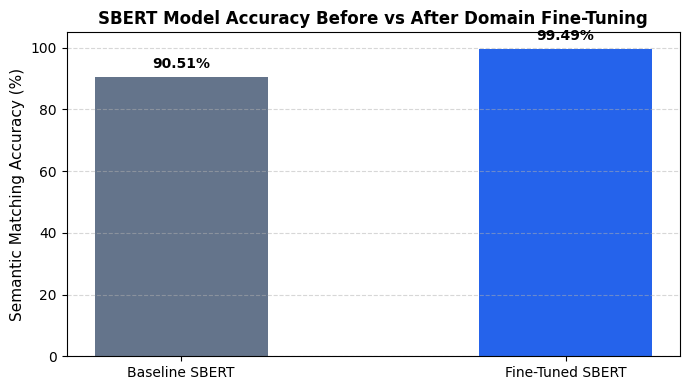

In [9]:
fine_tuned_model = SentenceTransformer(output_dir, device=device)
fine_tuned_results = evaluator(fine_tuned_model)
fine_tuned_score = extract_score(fine_tuned_results)

gain = (fine_tuned_score - baseline_score) * 100

print("="*60)
print("EXPERIMENTAL EVALUATION RESULTS (CHAPTER 4)")
print("="*60)
print(f"1. Baseline Pre-Trained (all-MiniLM-L6-v2): {baseline_score * 100:.2f}%")
print(f"2. Fine-Tuned Domain SBERT Model:          {fine_tuned_score * 100:.2f}%")
print(f"3. Accuracy Improvement:                    +{gain:.2f}%")
print("="*60)

# Plot comparison chart
plt.figure(figsize=(7, 4))
models = ['Baseline SBERT', 'Fine-Tuned SBERT']
scores = [baseline_score * 100, fine_tuned_score * 100]
colors = ['#64748b', '#2563eb']

bars = plt.bar(models, scores, color=colors, width=0.45)
plt.ylim(0, 105)
plt.ylabel('Semantic Matching Accuracy (%)', fontsize=11)
plt.title('SBERT Model Accuracy Before vs After Domain Fine-Tuning', fontsize=12, fontweight='bold')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
test_scenarios = [
    # Technical / Telecom
    (
        "Excavator severed the primary 48-core trunk optical cable outside business park. All offices offline.",
        "Lead Fiber Splicer with FOA Level 3 certification, OTDR trace testing, and ribbon fusion splicing."
    ),
    # Technical / Electrical
    (
        "Main 3-phase 415V distribution board sparking in commercial basement. Breaker tripped.",
        "Commercial Electrical Engineer holding EPRA Class A license, 3-phase switchboard specialist."
    ),
    # Everyday / Handyman
    (
        "Need a 55-inch smart TV mounted securely on living room gypsum wall with heavy-duty swivel bracket.",
        "Professional Handyman specializing in heavy-duty TV wall mounting, gypsum butterfly anchors, and cable trunking."
    ),
    # Everyday / Water Heating
    (
        "Lorenzetti instant shower running ice-cold water and 20A breaker trips immediately when switched to high heat.",
        "Water Heating & Instant Shower Technician experienced in Lorenzetti heating element replacement and dedicated 30A wiring."
    ),
    # Everyday / Satellite TV
    (
        "DStv decoder showing E48-32 No Signal error after rain storm. Rooftop dish moved.",
        "DStv Accredited Satellite Installer equipped with digital signal meter, dish azimuth realignment, and LNB replacement."
    ),
    # Everyday / Roadside Auto
    (
        "Car parked in estate basement won't start. Dashboard lights click and flicker; need emergency jumpstart.",
        "Mobile Auto-Electrician with emergency battery booster pack, alternator voltage diagnostics, and starter motor overhaul."
    ),

    (
        "My shower head showed some sparks",
        "plumber"
    )
]

print("INFERENCE VERIFICATION (TASK <-> PROFILE SIMILARITY):")
print("-"*80)
for task_text, profile_text in test_scenarios:
    vec_task = fine_tuned_model.encode(task_text)
    vec_prof = fine_tuned_model.encode(profile_text)
    similarity = float(util.cos_sim(vec_task, vec_prof)[0][0])

    print(f"Task:     {task_text}")
    print(f"Profile:  {profile_text}")
    print(f"Cosine Match Score: {similarity:.4f} ({(similarity*100):.1f}% Match)\n")

INFERENCE VERIFICATION (TASK <-> PROFILE SIMILARITY):
--------------------------------------------------------------------------------
Task:     Excavator severed the primary 48-core trunk optical cable outside business park. All offices offline.
Profile:  Lead Fiber Splicer with FOA Level 3 certification, OTDR trace testing, and ribbon fusion splicing.
Cosine Match Score: 0.4488 (44.9% Match)

Task:     Main 3-phase 415V distribution board sparking in commercial basement. Breaker tripped.
Profile:  Commercial Electrical Engineer holding EPRA Class A license, 3-phase switchboard specialist.
Cosine Match Score: 0.5030 (50.3% Match)

Task:     Need a 55-inch smart TV mounted securely on living room gypsum wall with heavy-duty swivel bracket.
Profile:  Professional Handyman specializing in heavy-duty TV wall mounting, gypsum butterfly anchors, and cable trunking.
Cosine Match Score: 0.7101 (71.0% Match)

Task:     Lorenzetti instant shower running ice-cold water and 20A breaker trips imme